## Исследование фичей: праздники

## Вопрос

---

Достаточно ли бинарного `is_holiday`, или нужна более богатая кодировка праздников?

Подвопросы (и где разбираются):

1. Разброс спроса по праздникам огромный (1,000–7,400, среднее ~4,500) — это «тип» праздника или посторонние факторы (рост, сезон)? — **§1**
2. Объясняет ли разброс температура? — **§2**
3. Главный искажающий фактор — рост сервиса +65% за год; снимают ли его фичи `is_holiday`, `days_since_launch`, `month`? — **§1–2**
4. Влияет ли день недели, на который выпал праздник? — **§3**
5. Различаются ли registered и direct в праздники? — **§4**

> **Дисциплина данных.** Анализ описательный, на всём периоде 2011–2012 — для понимания, не для отбора.
> Отбор фич и модели идёт на validation в [eda_and_modeling.ipynb](eda_and_modeling.ipynb), test нетронут до финала.
> Полный период здесь безопасен потому, что вывод **консервативный** (грубый `is_holiday`, без богатой кодировки) —
> это отказ от фичи, а не подгонка под данные: переобучить им test нельзя. А дробить 21 праздник на train/test ещё и статистически бессмысленно.

## Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

# Тяжёлые данные — из выхода пайплайна (ассет hourly_by_location, single source of truth).
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])
fd["date"] = fd["datetime_hourly"].dt.normalize()

# Имена праздников — отдельно из holidays.csv: holiday_name нужен только для разбора
# здесь, это не фича модели, поэтому в ML-датасет он не идёт.
holiday_names = pd.read_csv(DATA_RAW / "holidays.csv")
holiday_names["date"] = pd.to_datetime(holiday_names["date"]).dt.normalize()

## Дневная агрегация

---

Дневная таблица: суммарные аренды (total / registered / direct), средняя температура,
флаг и название праздника, год и месяц.

In [3]:
# Дневной агрегат из hourly_by_location: total / registered / direct по дате (сумма по локациям),
# средняя температура, флаг праздника. Имя праздника подмешиваем из holiday_names.
daily = fd.groupby("date").agg(
    daily_rentals=("total_rentals", "sum"),
    daily_registered=("registered_rentals", "sum"),
    daily_direct=("direct_pickups", "sum"),
    avg_temp=("temperature_c", "mean"),
    is_holiday=("is_holiday", "max"),
).reset_index()
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["day_of_week"] = daily["date"].dt.dayofweek
daily = daily.merge(holiday_names[["date", "holiday"]], on="date", how="left")

regular = daily[daily["is_holiday"] == 0]
holidays_df = daily[daily["is_holiday"] == 1]
regular_day_mean = regular["daily_rentals"].mean()

print(f"Обычных дней: {len(regular)}, праздничных: {len(holidays_df)}")
print(f"Средний обычный день: {regular_day_mean:,.0f} аренд")

Обычных дней: 710, праздничных: 21
Средний обычный день: 4,527 аренд


## 1. Эффект праздника: локальная база ±15 дней

---

Сравниваем аренды каждого праздника со средним по **обычным дням в пределах ±15 дней** от него.
Такая локальная база убирает сразу два искажения — рост сервиса и сезон, — потому что берёт «соседние условия», а не среднее по всему периоду (который сильно меняется во времени).

Отклонение считаем в абсолюте и в **процентах** (проценты сравнимы между сезонами: летом крупнее и база, и праздник). День недели в базе не выравниваем — обычный будний эффект мал (~4%, [trends §4](exploration_time_trends.ipynb)). Перенос праздника на понедельник (observed) — отдельный случай, разбираем в §3. Праздники из базы исключаем.

In [4]:
WINDOW = pd.Timedelta(days=15)
reg_dates = pd.to_datetime(regular["date"])  # date -> Timestamp для арифметики окна

def local_base(holiday_date):
    """Среднее простых дней в ±15 дней от праздника + размер базы."""
    near = regular.loc[(reg_dates - pd.Timestamp(holiday_date)).abs() <= WINDOW, "daily_rentals"]
    return near.mean(), int(near.shape[0])

holidays_df = holidays_df.copy()
base = holidays_df["date"].map(local_base)
holidays_df["base_local"] = [b[0] for b in base]
holidays_df["n_base"] = [b[1] for b in base]
holidays_df["dev_abs"] = holidays_df["daily_rentals"] - holidays_df["base_local"]
holidays_df["dev_pct"] = holidays_df["dev_abs"] / holidays_df["base_local"] * 100

holiday_effect = holidays_df.sort_values("dev_pct")[
    ["date", "holiday", "year", "daily_rentals", "base_local", "dev_abs", "dev_pct"]
]
print(f"дней в локальной базе: min={holidays_df['n_base'].min()}  max={holidays_df['n_base'].max()}\n")
print(holiday_effect.round(1).to_string(index=False))
print(f"\nмедиана: {holidays_df['dev_pct'].median():.0f}%   "
      f"спад >5%: {(holidays_df['dev_pct'] < -5).sum()}   "
      f"рост >5%: {(holidays_df['dev_pct'] > 5).sum()}   "
      f"норма ±5%: {(holidays_df['dev_pct'].abs() <= 5).sum()}  (из {len(holidays_df)})")

дней в локальной базе: min=21  max=30

      date                                holiday  year  daily_rentals  base_local  dev_abs  dev_pct
2012-12-25                          Christmas Day  2012           1013      3576.1  -2563.1    -71.7
2011-11-24                       Thanksgiving Day  2011           1495      3242.5  -1747.5    -53.9
2011-12-26               Christmas Day (observed)  2011           1317      2834.0  -1517.0    -53.5
2012-11-22                       Thanksgiving Day  2012           2425      5163.4  -2738.4    -53.0
2011-02-21                  Washington's Birthday  2011           1107      1808.7   -701.7    -38.8
2012-01-02              New Year's Day (observed)  2012           1951      2716.9   -765.9    -28.2
2012-01-16 Dr. Martin Luther King, Jr.'s Birthday  2012           2298      3189.5   -891.5    -28.0
2012-10-08                           Columbus Day  2012           5478      7091.3  -1613.3    -22.8
2011-09-05                              Labor Day  2

/tmp/claude-508/ipykernel_77603/1938885229.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(holiday_effect.round(1).to_string(index=False))


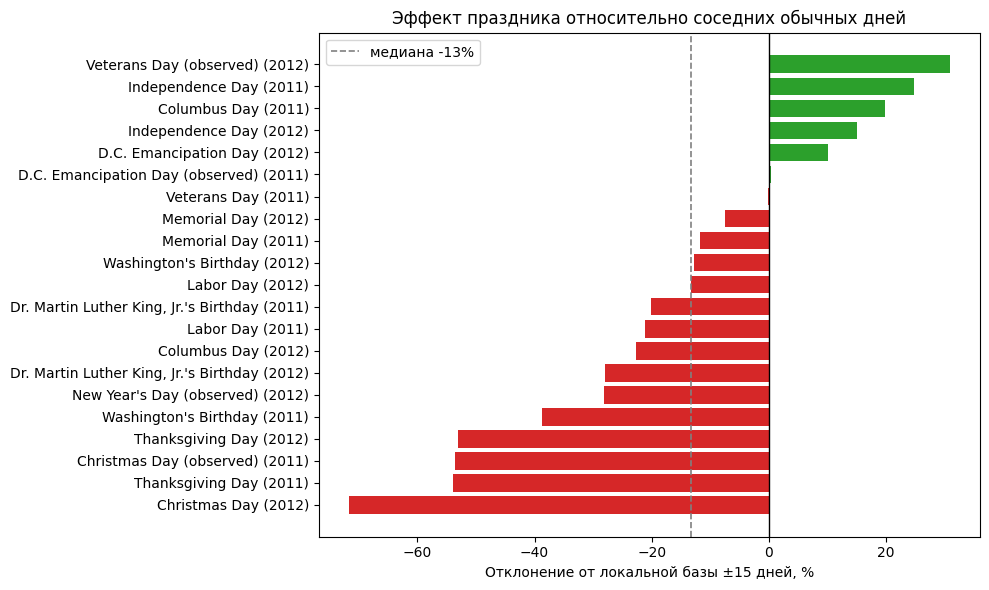

In [5]:
he = holidays_df.sort_values("dev_pct")
labels = he["holiday"] + " (" + he["year"].astype(str) + ")"
colors = ["#d62728" if v < 0 else "#2ca02c" for v in he["dev_pct"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, he["dev_pct"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(he["dev_pct"].median(), color="grey", linestyle="--", linewidth=1.2,
           label=f"медиана {he['dev_pct'].median():.0f}%")
ax.set_xlabel("Отклонение от локальной базы ±15 дней, %")
ax.set_title("Эффект праздника относительно соседних обычных дней")
ax.legend()
plt.tight_layout()
plt.show()

### Наблюдения

- С локальной базой картина меняется: праздник чаще **снижает** спрос. Медиана отклонения **−13%**: из 21 праздника 14 ниже соседних будней (>5%) и только 5 выше. Среднее по всему периоду это скрывало — спад и рост гасили друг друга из-за смешения сезонов и роста сервиса.
- Крайние случаи логичны. Сильный спад — на зимних/семейных праздниках: Christmas −72%, Thanksgiving −54%, плюс Washington, MLK, New Year. Рост — на «активных», уличных: Independence Day (+25%/+15% по годам), Veterans (observed) +31%, Columbus 2011.
- **Но год к году эффект нестабилен.** Из 10 праздников, что есть в обоих годах, близкое значение (≤5 п.п.) дают лишь 2; в среднем расхождение ~16 п.п., а два меняют знак (Columbus +20%→−23%, Veterans −0.2%→+31%). Часть скачков — из-за переноса на понедельник (observed, см. §3), но Columbus прыгает на 43 п.п. при том же понедельнике, то есть остаётся и просто шум на малой выборке.

**Для модели:** бинарный `is_holiday` усреднит всё в спад −13% и потеряет крайние случаи. Но кодировать каждый праздник отдельно на 21 наблюдении опасно — переобучимся. Разумный минимум — три обычные фичи `is_holiday`, `days_since_launch`, `month` (их взаимодействие соберёт дерево). Богатую кодировку проверим экспериментом (ablation) на тесте, но больших надежд нет — детали в [eda_and_modeling.ipynb](eda_and_modeling.ipynb).

## 2. Перекрёстные проверки (кратко)

---

Локальная база §1 уже контролирует и рост, и сезон. Здесь — две короткие проверки, которые к ней привели: объясняют ли разброс **температура** и **рост сервиса**.

`residual` (факт минус линейный тренд по температуре) считаем здесь — он понадобится в §3.

In [6]:
# Контроль на температуру: линейный тренд по обычным дням, остаток = факт − предсказание.
coef = np.polyfit(regular["avg_temp"], regular["daily_rentals"], 1)
pred_fn = np.poly1d(coef)

regular = regular.copy()
holidays_df = holidays_df.copy()
regular["residual"] = regular["daily_rentals"] - pred_fn(regular["avg_temp"])
holidays_df["residual"] = holidays_df["daily_rentals"] - pred_fn(holidays_df["avg_temp"])

reg_std = regular["residual"].std()
outside_1std = (holidays_df["residual"].abs() > reg_std).sum()

# Рост: вариация одного и того же праздника между годами (в остатках).
paired = holidays_df.pivot_table(index="holiday", columns="year", values="residual").dropna()
cross_year = (paired[2012] - paired[2011]).abs().mean()

print(f"std остатков обычных дней:       {reg_std:,.0f}")
print(f"праздников за ±1 std после t°:    {outside_1std} / {len(holidays_df)}  -> температура не объясняет")
print(f"среднее |разницы| год-к-году:    {cross_year:,.0f}  (~ std обычных дней)")

std остатков обычных дней:       1,512
праздников за ±1 std после t°:    8 / 21  -> температура не объясняет
среднее |разницы| год-к-году:    1,659  (~ std обычных дней)


### Наблюдения

- **Температура разброс не объясняет.** Даже после поправки на температуру 8 из 21 праздника выходят за ±1 std обычных дней (std ≈ 1500). Дело не в погоде.
- **Главный фактор — рост.** Разница одного праздника между годами в остатках (~1660) сравнима со std обычных дней (~1500), поэтому раньше выглядела как шум. Но локальная база §1 показала: год к году праздник всё равно нестабилен — рост она убирает лишь частично, остальное это день недели и шум.
- Обе проверки поглощены локальной базой §1, оставлены кратко «как мы к ней пришли». `residual` используется в §3.

## 3. День недели праздника

---

Independence Day 2012 выпал на среду и показал самый высокий остаток.
Проверяем: коррелирует ли день недели праздника с остатком?

In [7]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
hol_dow = holidays_df[["holiday", "year", "day_of_week", "residual"]].copy()
hol_dow["день_недели"] = hol_dow["day_of_week"].map(dict(enumerate(dow_names)))

print(hol_dow.sort_values("residual")[["holiday", "year", "день_недели", "residual"]].to_string(index=False))

                               holiday  year день_недели     residual
                             Labor Day  2011          Пн -2339.534289
                      Thanksgiving Day  2011          Чт -2224.806009
                         Christmas Day  2012          Вт -2167.751926
                 Washington's Birthday  2011          Пн -2153.008212
              Christmas Day (observed)  2011          Пн -2064.777447
                          Memorial Day  2011          Пн -1985.399496
Dr. Martin Luther King, Jr.'s Birthday  2011          Пн -1425.387906
             New Year's Day (observed)  2012          Пн -1111.322995
                      Thanksgiving Day  2012          Чт -1076.547561
      D.C. Emancipation Day (observed)  2011          Пт -1075.720662
Dr. Martin Luther King, Jr.'s Birthday  2012          Пн  -218.183421
                          Veterans Day  2011          Пт   -29.365528
                      Independence Day  2011          Пн     2.670171
                 Was

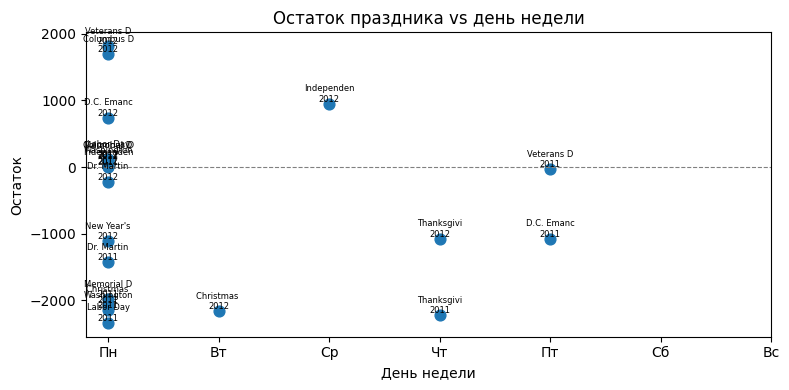

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(hol_dow["day_of_week"], hol_dow["residual"], s=60)
for _, row in hol_dow.iterrows():
    ax.annotate(f"{row['holiday'][:10]}\n{row['year']}",
                (row["day_of_week"], row["residual"]),
                fontsize=6, ha="center", va="bottom")
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("День недели")
ax.set_ylabel("Остаток")
ax.set_title("Остаток праздника vs день недели")
plt.tight_layout()
plt.show()

### Наблюдения

- Почти все праздники США приходятся на **понедельник** (15 из 21), так что разброса по дню недели почти нет. А внутри понедельника остатки гуляют от −2300 до +1800 — значит дело не в дне недели.
- §1 подтверждает с другой стороны: часть годовых скачков совпадает с переносом на понедельник (Veterans Пт→Пн, Christmas Пн→Вт), но Columbus скачет на 43 п.п. при том же понедельнике. День недели объясняет лишь часть, остальное — шум.
- Independence Day на среду (2012, +953) против понедельника (2011, +3) — слишком мало точек для вывода.

**Для модели:** отдельную фичу «день недели праздника» не вводим — вариации почти нет, а внутри неё шум. День недели и так есть в модели общей фичей `day_of_week`.

## 4. Registered vs direct в праздники

---

Сегменты ведут себя по-разному в целом (4.3x по объёму). Вопрос: усиливается ли
разница в праздники? Если да — это аргумент за раздельное моделирование.

In [9]:
segment_daily = daily[["date", "is_holiday", "daily_registered", "daily_direct"]].copy()
segment_daily["reg_share"] = (
    segment_daily["daily_registered"]
    / (segment_daily["daily_registered"] + segment_daily["daily_direct"])
)

reg_share_regular = segment_daily[segment_daily["is_holiday"] == 0]["reg_share"]
reg_share_holiday = segment_daily[segment_daily["is_holiday"] == 1]["reg_share"]

print(f"Доля registered (обычные дни):  mean={reg_share_regular.mean():.3f}, std={reg_share_regular.std():.3f}")
print(f"Доля registered (праздники):    mean={reg_share_holiday.mean():.3f}, std={reg_share_holiday.std():.3f}")

Доля registered (обычные дни):  mean=0.827, std=0.106
Доля registered (праздники):    mean=0.728, std=0.125


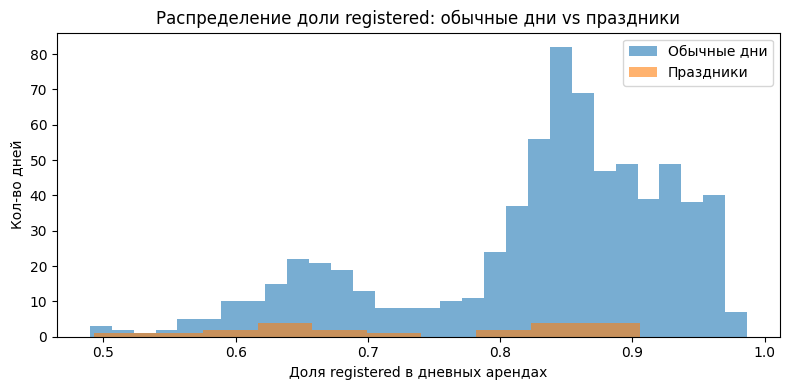

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reg_share_regular, bins=30, alpha=0.6, label="Обычные дни")
ax.hist(reg_share_holiday, bins=10, alpha=0.6, label="Праздники")
ax.set_xlabel("Доля registered в дневных арендах")
ax.set_ylabel("Кол-во дней")
ax.set_title("Распределение доли registered: обычные дни vs праздники")
ax.legend()
plt.tight_layout()
plt.show()

### Наблюдения

- В праздники доля registered **падает** с 0.83 до 0.73 — относительно больше direct-пикапов (≈27% против ≈17% в обычные дни). Значит сегменты реагируют на праздники по-разному.
- Сигнал устойчивый, но умеренный, и разброс в праздники выше (std 0.11 → 0.13) — на 21 дне это слабая опора.

**Для модели:** различие реальное, но само по себе не оправдывает отдельные модели для `registered` и `direct` — усложнение ради сдвига доли в ~10 п.п. Пока моделируем total; отдельный таргет остаётся опцией (`config.target`), если понадобится точность по сегментам.

## Выводы

---

**Подтверждено:**
- Бинарный `is_holiday` слишком грубый: усредняет эффект (медиана −13%) и теряет крайние случаи — зимние/семейные праздники (спад до −72%) против активных (рост до +31%).
- Но кодировать праздники богаче на 21 наблюдении нельзя — год к году нестабильно (только 2 из 10 совпадают в пределах 5 п.п., два меняют знак), переобучимся.
- Разброс праздников — это в основном рост и сезон, а не «тип» сам по себе (§1–2). Главный фактор — рост +65% (см. [trends](exploration_time_trends.ipynb)); температура не при чём.
- День недели праздника (§3) и сегмент registered/direct (§4) — сигнал слабый, отдельных фич и моделей не вводим.

**Рекомендация: три раздельные фичи — `is_holiday`, `days_since_launch`, `month` (не новый агрегат).** `days_since_launch` убирает рост, `month` даёт сезон, а дерево частично восстановит «тип» праздника через сезон (зимние спады против летних подъёмов), не зная названия. Это компромисс, а не полное решение: чисто «типовой» остаток (Memorial и Labor — лето, но спад) на 21 дне ненадёжен, поэтому богатую кодировку проверяем экспериментом (ablation) на тесте, без больших ожиданий.